## 1. What this notebook computes

The Kohn-Sham states of the Revision record are **instantaneous** states: at each
slice $a_{4,0}$ of the history the solver finds the ground state of the Hamiltonian
of that instant. But the history moves on: $a_4 = A H x_4$ grows with the time
$x_4$. Does the gas follow the instantaneous ground state, or does the motion of
the background kick particles into higher levels? This is the question of
**adiabaticity**. This notebook

- explains the measure $Q_{nm}$ of the Revision record and where it comes from;
- recomputes in plain Python, with the solver's own shooting method, every
  allowed transition of the free states $N = 136$ and $N = 688$ at the five slices,
  and reproduces the largest value $Q_{max}$, the pair of levels, their energy
  difference and the matrix element recorded by the Rust solver;
- checks the Hellmann-Feynman theorem $d\varepsilon_n/da_4 = \langle n|\partial_a
  h|n\rangle$ and the energy derivative $dE/da_4$;
- reproduces the **Fermi-level crossing** of the demonstration state $N = 696$, where
  the instantaneous ground state and the adiabatically followed state differ.

It draws six figures and needs no Rust.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 15c (Adiabaticity along the deflating history) is the file
`Revision/textbook/notebooks/15c_adiabaticity.ipynb` of the repository Dirac_claude. It
explains when the instantaneous Kohn-Sham states of dirac16complex can be followed along
the deflating history (the adiabatic approximation), recomputes in plain Python the
adiabaticity measure Q of every allowed transition of the free states N = 136 and N = 688
at the five slices, reproduces the largest Q, its pair of levels, its energy difference
and its matrix element from the committed Revision record, checks the Hellmann-Feynman
theorem and the energy derivative along the history, and reproduces the Fermi-level
crossing of the demonstration state N = 696. It needs a computer with Windows 11, macOS
or Linux, an internet connection for the installation, the program Git, and Python 3.12
or newer (the notebooks were built with Python 3.14.5) with these packages at exactly
these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
notebook itself imports numpy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 15c_adiabaticity.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 15c_adiabaticity.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
15c_adiabaticity.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/15c.captions.json`
- `Revision/textbook/figures/15c_1_transition_orbitals.png`
- `Revision/textbook/figures/15c_2_q_by_pair.png`
- `Revision/textbook/figures/15c_3_q_history.png`
- `Revision/textbook/figures/15c_4_hellmann_feynman.png`
- `Revision/textbook/figures/15c_5_fermi_crossing.png`
- `Revision/textbook/figures/15c_6_q_map.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 12 CHECKS PASSED (notebook 15c)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/15c_adiabaticity.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 15c_adiabaticity.ipynb
      python -m nbconvert --execute --inplace 15c_adiabaticity.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 15c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 15c (Adiabaticity along the deflating history) is the file
# Revision/textbook/notebooks/15c_adiabaticity.ipynb of the repository Dirac_claude. It
# explains when the instantaneous Kohn-Sham states of dirac16complex can be followed
# along the deflating history (the adiabatic approximation), recomputes in plain Python
# the adiabaticity measure Q of every allowed transition of the free states N = 136 and N
# = 688 at the five slices, reproduces the largest Q, its pair of levels, its energy
# difference and its matrix element from the committed Revision record, checks the
# Hellmann-Feynman theorem and the energy derivative along the history, and reproduces
# the Fermi-level crossing of the demonstration state N = 696. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other packages
# run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 15c_adiabaticity.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 15c_adiabaticity.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 15c_adiabaticity.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/15c.captions.json
# - Revision/textbook/figures/15c_1_transition_orbitals.png
# - Revision/textbook/figures/15c_2_q_by_pair.png
# - Revision/textbook/figures/15c_3_q_history.png
# - Revision/textbook/figures/15c_4_hellmann_feynman.png
# - Revision/textbook/figures/15c_5_fermi_crossing.png
# - Revision/textbook/figures/15c_6_q_map.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 12 CHECKS PASSED (notebook 15c)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/15c_adiabaticity.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 15c_adiabaticity.ipynb
#     python -m nbconvert --execute --inplace 15c_adiabaticity.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "15c"  # this notebook: chapter 15, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 15c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Instantaneous (adiabatic) state**: the ground state of the Hamiltonian
  $h(a_{4,0})$ of one instant of the history (one slice $a_{4,0}$); the history
  itself keeps moving, with 3-space inflating and the extra times deflating.
- **Adiabatic**: a change of the Hamiltonian slow enough that a system in an
  eigenstate stays in the eigenstate that continues it (the adiabatic theorem).
- **Transition**: a jump of a particle from an occupied level $n$ to an empty level
  $m$; its **amplitude** is a number whose square is the probability of the jump.
- **Matrix element** $\langle n|X|m\rangle$: for orbitals $\chi_n = (a_n, i b_n)$
  the integral $\int \chi_n^\dagger X \chi_m\,dy$; for $X = \sigma_3$ it is
  $\int (a_n a_m - b_n b_m)\,dy$.
- **Sector**: the shell $n_2$, the block type $j$ and the brane parity. The exact
  evolution conserves all three, so transitions happen only inside a sector.
- **Adiabaticity measure** $Q_{nm} = A H |\langle n|\partial_a h|m\rangle| /
  (\varepsilon_n - \varepsilon_m)^2$: the first-order amplitude of the jump
  $n \to m$; $Q_{max}$ is the largest over all allowed pairs.
- **Hellmann-Feynman theorem**: the derivative of a level with respect to a
  parameter equals the matrix element of the derivative of the Hamiltonian.
- **Aufbau**: filling the lowest levels with the $N$ particles. **Fermi-level
  crossing**: an empty level comes down below an occupied one along the history,
  so the aufbau filling changes. **Adiabatically continued state**: the state
  that keeps the occupations of the first slice.
- **Open shell**: a degenerate group of levels only partly filled.
- **Heat map**: a table of numbers drawn as coloured squares.

## 4. The physical and mathematical situation

In the author's metric 3-space $x_1, x_2, x_3$ inflates with $e^{a_4}$ and the three
extra times $x_5, x_6, x_7$ deflate with $e^{-a_4}$; the history is $a_4 = A H x_4$
with $A = 1$, a PRESCRIBED BACKGROUND (Revision record ks-theory.json,
adiabaticity.historyStatus). In the hidden coordinate $y$ the Kohn-Sham orbitals of a
sector obey exactly (ks-theory.json, adiabaticity.exactEvolution)

$$i\,\frac{\partial \chi}{\partial x_4} = h(a_4(x_4))\,\chi, \qquad
h_j = j\left[-i\sigma_1 \frac{d}{dy} + M\sigma_2 + \kappa k \sigma_3\right] + v,
\qquad \kappa = e^{-Hy - a_4}.$$

**Where $Q$ comes from.** Write $\chi = \sum_m c_m(x_4)\,e^{-i\theta_m}\,\phi_m$ with
the instantaneous orbitals $h\phi_m = \varepsilon_m\phi_m$ and the phases
$\theta_m = \int \varepsilon_m\,dx_4$. Inserting into the equation and projecting
on $\phi_m$ gives, line by line: (1) the left side gives
$i\dot c_m + \varepsilon_m c_m + i\sum_n c_n e^{i(\theta_m - \theta_n)}\langle
m|\dot\phi_n\rangle$ (product rule; the dot is $d/dx_4$); (2) the right side gives
$\varepsilon_m c_m$; (3) so $\dot c_m = -\sum_n c_n e^{i(\theta_m-\theta_n)}\langle
m|\dot\phi_n\rangle$. (4) Differentiating $h\phi_n = \varepsilon_n\phi_n$ and
projecting on $\phi_m$ ($m \ne n$) gives $\langle m|\dot\phi_n\rangle = \dot a_4
\langle m|\partial_a h|n\rangle/(\varepsilon_n - \varepsilon_m)$. (5) Starting from
$c_n = 1$, integrating (3) over a time in which the phase $e^{i(\varepsilon_m -
\varepsilon_n)x_4}$ turns many times gives an amplitude of size
$|\langle m|\dot\phi_n\rangle|/|\varepsilon_m - \varepsilon_n|$ (the integral of
$e^{i\omega t}$ is $e^{i\omega t}/(i\omega)$), that is, with $\dot a_4 = AH$,

$$Q_{nm} = A H\,\frac{|\langle n|\partial_a h|m\rangle|}{(\varepsilon_n -
\varepsilon_m)^2}, \qquad \text{transition probability} \approx Q_{nm}^2 .$$

The evolution is adiabatic when every $Q_{nm} \ll 1$.

**The derivative of $h$.** Without interaction ($\lambda = 0$) only $\kappa$ depends
on $a_4$, and $\partial\kappa/\partial a_4 = -\kappa$, so
$\partial_a h_j = -j\kappa k\sigma_3$ and
$\langle n|\partial_a h|m\rangle = -j k e^{-a_{4,0}}\int e^{-Hy}(a_n a_m - b_n b_m)\,dy$.
(With interaction the self-consistent potentials change too; the solver includes
their derivatives. This notebook recomputes the free states $\lambda = 0$ and shows
the recorded values of all states.)

**Hellmann-Feynman.** For $m = n$ the same steps give
$d\varepsilon_n/da_4 = \langle n|\partial_a h|n\rangle$, and the energy of the free
gas, $E = \sum g f\varepsilon$, changes by $dE/da_4 = \sum g f\langle n|\partial_a
h|n\rangle$.

The non-adiabatic (time-dependent) problem itself is OPEN; $Q$ is a first-order
estimate. Units $H = m = 1$, $L = 3$, $\Delta k = 0.25$.

## 5. The solver's shooting method in Python

The next cell defines the solver's method for the free problem ($M = m$, $v = 0$):
the grid of $G = 900$ RK4 steps on $[-3, 0]$ with its fine grid of step ends and
midpoints, `shoot` (integrate the block equation from the tip, where $b = 0$, to the
brane, and follow the Pruefer angle $\theta = \mathrm{atan2}(b, a)$; the phase
$\Phi = j\theta(0)$ increases with $\varepsilon$ and equals $l\pi$ (even parity) or
$\pi/2 + l\pi$ (odd parity) at the level with label $l$; `shoot` also returns the
derivative $d\Phi/d\varepsilon = \int r^2 dy/r(0)^2$, $r^2 = a^2 + b^2$, with the
integral by the trapezoid rule on the step ends, as in the solver), `find_level`
(the solver's Newton method inside a bracket for $\Phi(\varepsilon) = $ target: walk
with doubling steps until the target is bracketed, then Newton steps, with bisection
whenever a Newton step leaves the bracket or the previous step did not halve the
error; stop when the bracket or a Newton step is below $10^{-13}$), and `orbital`
(the normalised orbital on the fine grid, with cubic Hermite midpoints). The
comments say what each line does.

In [2]:
import csv  # reads the tables (CSV files) of the Revision record
import math  # exp, sqrt, atan2, pi for single numbers

import numpy as np  # arrays of numbers

L, STEPS = 3.0, 900  # tip cutoff and number of RK4 steps (the solver's values)
POINTS = 2 * STEPS + 1  # step ends and midpoints
STEP = L / STEPS
Y = np.array([-L * ((POINTS - 1 - f) / (POINTS - 1)) for f in range(POINTS)])
EW_LIST = [math.exp(-y) for y in Y.tolist()]  # e^{-Hy} with H = 1, as the solver
EW = np.array(EW_LIST)
SIMPSON = np.full(POINTS, 2.0 * STEP / 6.0)  # Simpson weights on the fine grid
SIMPSON[1::2] = 4.0 * STEP / 6.0
SIMPSON[0] = SIMPSON[-1] = STEP / 6.0
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order


def shoot(eps, k, j, a4, store=False):
    """Free block (M = 1, v = 0): integrate tip -> brane; (Phi, dPhi/deps, nodes)."""
    kk = k * math.exp(-a4)
    a, b, theta, raw, area, r2_prev = 1.0, 0.0, 0.0, 0.0, 0.0, 1.0
    je = j * eps  # j (eps - v) with v = 0
    nodes = [(a, b)] if store else None
    for i in range(STEPS):
        k0 = kk * EW_LIST[2 * i]  # kappa k at the start of the step
        k1 = kk * EW_LIST[2 * i + 1]  # at its midpoint
        k2 = kk * EW_LIST[2 * i + 2]  # at its end
        p1a, p1b = a - (k0 + je) * b, (je - k0) * a - b  # (a', b') with M = 1
        aa, bb = a + 0.5 * STEP * p1a, b + 0.5 * STEP * p1b
        p2a, p2b = aa - (k1 + je) * bb, (je - k1) * aa - bb
        aa, bb = a + 0.5 * STEP * p2a, b + 0.5 * STEP * p2b
        p3a, p3b = aa - (k1 + je) * bb, (je - k1) * aa - bb
        aa, bb = a + STEP * p3a, b + STEP * p3b
        p4a, p4b = aa - (k2 + je) * bb, (je - k2) * aa - bb
        a += STEP / 6.0 * (p1a + 2.0 * p2a + 2.0 * p3a + p4a)
        b += STEP / 6.0 * (p1b + 2.0 * p2b + 2.0 * p3b + p4b)
        new = math.atan2(b, a)  # the Pruefer angle, followed continuously:
        change = new - raw  # bring the change of angle into (-pi, pi]
        if change > math.pi:
            change -= 2.0 * math.pi
        elif change <= -math.pi:
            change += 2.0 * math.pi
        theta, raw = theta + change, new
        r2 = a * a + b * b
        area, r2_prev = area + 0.5 * STEP * (r2_prev + r2), r2  # trapezoid rule
        if store:
            nodes.append((a, b))
    return j * theta, area / r2_prev, nodes  # Phi and dPhi/deps = int r^2 / r(0)^2


def find_level(k, j, parity, label, a4, guess, tol=1e-13):
    """The level with this label: the solver's Newton method inside a bracket."""
    target = label * math.pi + (0.0 if parity == "even" else 0.5 * math.pi)
    e = guess
    g, d = shoot(e, k, j, a4)[:2]
    g -= target
    if g == 0.0:
        return e
    step = min(max(abs(g / d) * 1.2, 1e-4), 2.0)  # the first trial step
    if g < 0:  # Phi too small: walk up with doubling steps until Phi >= target
        lo = e
        while True:
            trial = lo + step
            gt, dt = shoot(trial, k, j, a4)[:2]
            gt -= target
            if gt >= 0:
                hi = trial  # [lo, hi] brackets the level
                if abs(gt) < abs(g):
                    e, g, d = trial, gt, dt  # keep the better end for Newton
                break
            lo, e, g, d = trial, trial, gt, dt
            step *= 2.0
    else:  # Phi too large: walk down until Phi <= target
        hi = e
        while True:
            trial = hi - step
            gt, dt = shoot(trial, k, j, a4)[:2]
            gt -= target
            if gt <= 0:
                lo = trial
                if abs(gt) < abs(g):
                    e, g, d = trial, gt, dt
                break
            hi, e, g, d = trial, trial, gt, dt
            step *= 2.0
    previous = math.inf
    while hi - lo > tol and g != 0.0:
        new = e - g / d  # Newton step, or bisection if it leaves the bracket
        bisect = not lo < new < hi or abs(g) > 0.5 * previous
        if bisect:
            new = 0.5 * (lo + hi)
        previous = abs(g)
        moved = abs(new - e)
        e = new
        g, d = shoot(e, k, j, a4)[:2]
        g -= target
        if g < 0:
            lo = e
        elif g > 0:
            hi = e
        if moved <= tol and not bisect:
            break  # a Newton step that moves less than tol: converged
    return e


def orbital(eps, k, j, a4):
    """Normalised orbital (a, b) on the fine grid; Hermite midpoints, Simpson norm."""
    nodes = np.array(shoot(eps, k, j, a4, store=True)[2])
    kap = k * math.exp(-a4) * EW[0::2]
    a_n, b_n = nodes[:, 0], nodes[:, 1]
    da = a_n - (kap + j * eps) * b_n  # derivatives at the step ends
    db = (j * eps - kap) * a_n - b_n
    a = np.zeros(POINTS)
    b = np.zeros(POINTS)
    a[0::2], b[0::2] = a_n, b_n
    a[1::2] = 0.5 * (a_n[:-1] + a_n[1:]) + STEP / 8.0 * (da[:-1] - da[1:])
    b[1::2] = 0.5 * (b_n[:-1] + b_n[1:]) + STEP / 8.0 * (db[:-1] - db[1:])
    norm = math.sqrt(float(np.sum(SIMPSON * (a * a + b * b))))
    return a / norm, b / norm


def da_h(k, j, a4, first, second):
    """<first| d_a h |second> = -j k e^{-a4} int e^{-y} (a1 a2 - b1 b2) dy."""
    s3 = first[0] * second[0] - first[1] * second[1]
    return -j * k * math.exp(-a4) * float(np.sum(SIMPSON * EW * s3))

## 6. The levels of the record, solved again

The next cell reads the level table of a free ground state from the record (for
example `ground/levels/N136_lam0_a00.csv`: for each level its shell $n_2$, the
number $r_3$ of momentum vectors in the shell, $k$, $j$, the parity, the label $l$,
the energy and the occupation $f$), keeps the sectors that contain an occupied
level (only there can a particle jump), and solves every level of these sectors
again in Python. Each energy must agree with the solver's to $10^{-12}$.

In [3]:
LEVELS = "Revision/kohn_sham/results/ground/levels"
SLICES = [0.0, 0.5, 1.0, 1.5, 2.0]


def state_id(n, a4, tag="lam0"):
    return f"N{n}_{tag}_a{round(10 * a4):02d}"


def solve_state(n, a4):
    """{sector: {label: (eps, f, k, r3, orbital)}} for the sectors with particles."""
    rows = list(csv.DictReader(open(repository_file(f"{LEVELS}/{state_id(n, a4)}.csv"),
                                    newline="", encoding="utf-8")))
    sectors = {}
    for row in rows:
        sector = (int(row["n2"]), int(row["j"]), row["parity"])
        sectors.setdefault(sector, []).append(row)
    solved, worst = {}, 0.0
    for sector, members in sectors.items():
        if all(float(row["f"]) < 0.5 for row in members):
            continue  # no particle in this sector: no transition starts here
        solved[sector] = {}
        for row in members:
            k, eps_rec = float(row["k"]), float(row["eps"])
            eps = find_level(k, sector[1], sector[2], int(row["label"]), a4, eps_rec)
            worst = max(worst, abs(eps - eps_rec))
            solved[sector][int(row["label"])] = (
                eps, float(row["f"]), k, int(row["r3"]), orbital(eps, k, sector[1], a4))
    return solved, worst


states = {}
worst_level = 0.0
for n in (136, 688):
    for a4 in SLICES:
        states[(n, a4)], worst = solve_state(n, a4)
        worst_level = max(worst_level, worst)
count = sum(len(levels) for state in states.values() for levels in state.values())
report("levels solved again (10 states)", count)
report("largest |eps(Python) - eps(solver)|", f"{worst_level:.1e}")
check(worst_level < 1e-12, "every level equals the solver's level within 1e-12",
      record=f"{LEVELS}/N136_lam0_a*.csv and N688_lam0_a*.csv, column eps")

RESULT levels solved again (10 states) = 270
RESULT largest |eps(Python) - eps(solver)| = 9.3e-14
PASS every level equals the solver's level within 1e-12
     reproduces Revision/kohn_sham/results/ground/levels/N136_lam0_a*.csv and
    N688_lam0_a*.csv, column eps


## 7. The pair of levels with the largest Q

For $N = 136$ at $a_{4,0} = 0$ the record names the pair with the largest $Q$: from
the brane-band level of the shell $n_2 = 4$ ($k = 0.5$, the highest occupied shell,
label 0) to the first bulk level of the same sector (label 1). The next cell draws
the two orbitals and the integrand $\kappa k(a_n a_m - b_n b_m)$ of their matrix
element: the band orbital is bound to the brane, the bulk orbital oscillates
across the interval, so their overlap partly cancels, and the energy difference
($2.05\,m$) is large.

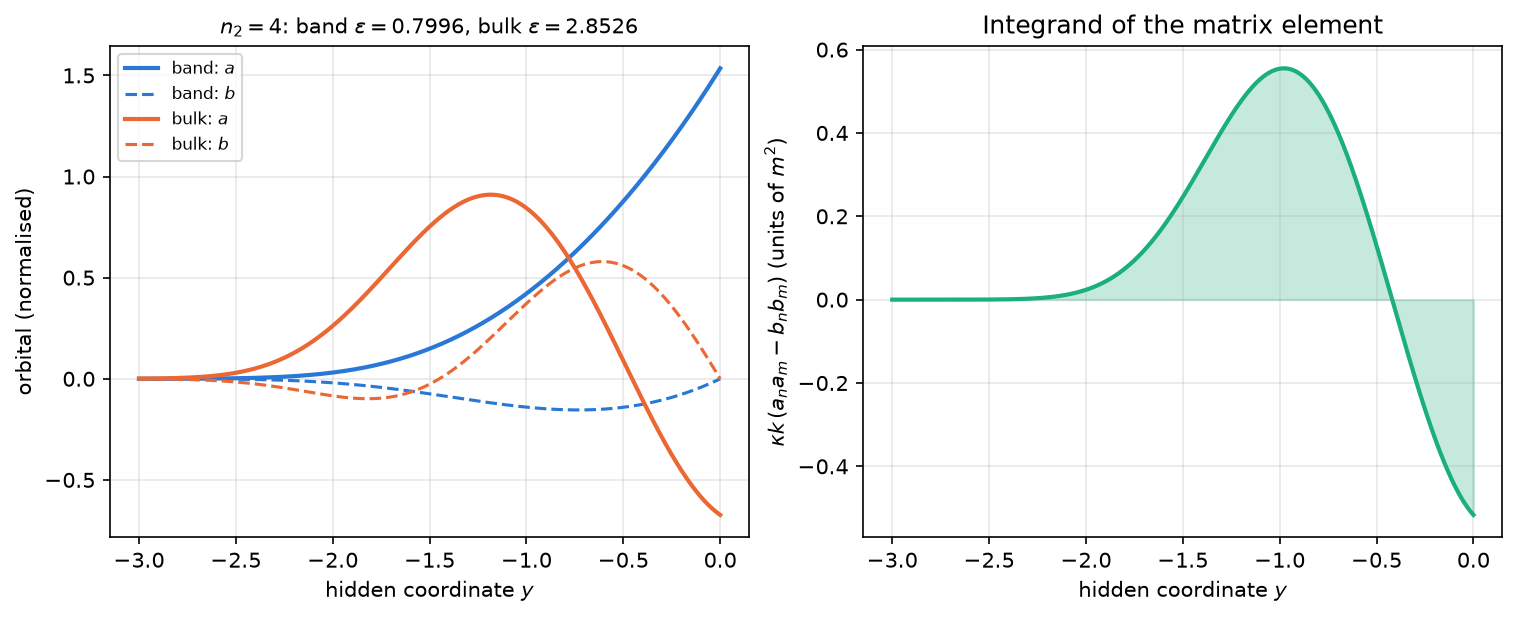

Figure 15c.1 saved as Revision/textbook/figures/15c_1_transition_orbitals.png
RESULT |<band| d_a h |bulk>| and Q for N = 136, a4,0 = 0 = 0.3588612167741,
    0.0851487731074


In [4]:
sector = (4, 1, "even")
band = states[(136, 0.0)][sector][0]  # (eps, f, k, r3, (a, b)) of label 0
bulk = states[(136, 0.0)][sector][1]  # label 1
k = band[2]
integrand = k * EW * (band[4][0] * bulk[4][0] - band[4][1] * bulk[4][1])
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
left.plot(Y, band[4][0], color=PALETTE[0], lw=2.0, label="band: $a$")
left.plot(Y, band[4][1], color=PALETTE[0], lw=1.5, ls="--", label="band: $b$")
left.plot(Y, bulk[4][0], color=PALETTE[1], lw=2.0, label="bulk: $a$")
left.plot(Y, bulk[4][1], color=PALETTE[1], lw=1.5, ls="--", label="bulk: $b$")
left.set_xlabel("hidden coordinate $y$")
left.set_ylabel("orbital (normalised)")
left.set_title(f"$n_2 = 4$: band $\\varepsilon = {band[0]:.4f}$, "
               f"bulk $\\varepsilon = {bulk[0]:.4f}$", fontsize=10)
left.legend(fontsize=8)
right.plot(Y, integrand, color=PALETTE[2], lw=2.0)
right.fill_between(Y, integrand, color=PALETTE[2], alpha=0.25)
right.set_xlabel("hidden coordinate $y$")
right.set_ylabel("$\\kappa k\\,(a_n a_m - b_n b_m)$ (units of $m^2$)")
right.set_title("Integrand of the matrix element")
save_figure(fig, "transition_orbitals",
            "Left: the orbitals (components $a$ solid, $b$ dashed; vertical axis, "
            "normalised) of the occupied brane-band level (blue) and the empty bulk "
            "level (orange) of the sector $n_2 = 4$, $j = +1$, even parity, of the "
            "free state $N = 136$ at $a_{4,0} = 0$, against $y$ (horizontal axis). "
            "Right: the integrand of their matrix element $\\langle n|\\partial_a h|"
            "m\\rangle$ (units of $m^2$); the size of its area is $0.3589\\,m$, and "
            "with the energy difference $2.053\\,m$ it gives $Q = 0.0851$, the "
            "largest of this state.")
element = abs(da_h(k, 1, 0.0, band[4], bulk[4]))
report("|<band| d_a h |bulk>| and Q for N = 136, a4,0 = 0",
       f"{element:.13f}, {element / (band[0] - bulk[0]) ** 2:.13f}")

## 8. Q for every allowed pair, and the comparison with the record

The next cell computes $Q_{nm}$ for every pair (occupied $n$, empty $m$, same sector)
of the ten free states $N = 136, 688$ at the five slices, finds the largest, and
compares the value, the pair (written as the record writes it,
`n2:j:parity:label -> n2:j:parity:label`), the energy difference and the matrix
element with the columns `Q_max`, `Q_max_pair`, `Q_max_delta_eps` and
`Q_max_matrix_element` of `adiabatic/adiabaticity.csv`.

In [5]:
ADIABATIC = "Revision/kohn_sham/results/adiabatic/adiabaticity.csv"
with open(repository_file(ADIABATIC), newline="", encoding="utf-8") as handle:
    adiabatic = {row["id"]: row for row in csv.DictReader(handle)}


def key_text(sector, label):
    return f"{sector[0]}:{sector[1]:+d}:{sector[2]}:{label}"


pairs = {}  # (n, a4) -> list of (Q, n2, label m) for the figure
worst_q, same_pairs = 0.0, True
say("   N  a4,0   Q_max    pair                          delta eps   matrix el.")
for (n, a4), state in states.items():
    best = (0.0, "", 0.0, 0.0)
    pairs[(n, a4)] = []
    for sector, levels in state.items():
        for ln, (en, fn, k, _, on) in levels.items():
            if fn < 0.5:
                continue
            for lm, (em, fm, _, _, om) in levels.items():
                if fm > 0.5:
                    continue
                element = abs(da_h(k, sector[1], a4, on, om))
                q = element / (en - em) ** 2  # A H = 1
                pairs[(n, a4)].append((q, sector[0], lm))
                if q > best[0]:
                    best = (q, f"{key_text(sector, ln)} -> {key_text(sector, lm)}",
                            abs(en - em), element)
    row = adiabatic[state_id(n, a4)]
    for value, column in ((best[0], "Q_max"), (best[2], "Q_max_delta_eps"),
                          (best[3], "Q_max_matrix_element")):
        worst_q = max(worst_q, abs(value / float(row[column]) - 1.0))
    same_pairs = same_pairs and best[1] == row["Q_max_pair"]
    say(f"{n:4d}  {a4:4.1f}  {best[0]:.5f}  {best[1]:28}  {best[2]:9.6f}"
        f"  {best[3]:9.6f}")
report("largest relative difference to the record", f"{worst_q:.1e}")
check(worst_q < 1e-9, "Q_max, its energy difference and matrix element reproduced",
      record=f"{ADIABATIC}, columns Q_max, Q_max_delta_eps, Q_max_matrix_element")
check(same_pairs, "the pair with the largest Q is the recorded pair",
      record=f"{ADIABATIC}, column Q_max_pair")

   N  a4,0   Q_max    pair                          delta eps   matrix el.
 136   0.0  0.08515  4:+1:even:0 -> 4:+1:even:1     2.052930   0.358861
 136   0.5  0.07456  4:+1:even:0 -> 4:+1:even:1     1.888369   0.265876
 136   1.0  0.06362  4:+1:even:0 -> 4:+1:even:1     1.745737   0.193883
 136   1.5  0.05275  4:+1:even:0 -> 4:+1:even:1     1.616341   0.137809
 136   2.0  0.03839  4:+1:even:0 -> 4:+1:even:1     1.524416   0.089223
 688   0.0  0.09345  11:+1:even:0 -> 11:+1:even:1   2.253405   0.474527
 688   0.5  0.08526  11:+1:even:0 -> 11:+1:even:1   2.055018   0.360061
 688   1.0  0.07469  11:+1:even:0 -> 11:+1:even:1   1.890122   0.266836
 688   1.5  0.06374  11:+1:even:0 -> 11:+1:even:1   1.747327   0.194603
 688   2.0  0.05289  11:+1:even:0 -> 11:+1:even:1   1.617688   0.138417
RESULT largest relative difference to the record = 6.8e-14
PASS Q_max, its energy difference and matrix element reproduced
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv, columns Q_m

The next cell draws all pairs of $N = 136$ and $N = 688$ at $a_{4,0} = 0$: $Q$
against the shell $n_2$ of the sector, coloured by the label $m$ of the empty
level. In every shell the jump to the next bulk level (label 1) dominates, and it
grows with $n_2$: the matrix element is proportional to $k$. The largest $Q$ belongs
to the highest occupied shell ($n_2 = 4$ for $N = 136$, $n_2 = 11$ for $N = 688$).
The zero modes ($n_2 = 0$) cannot jump at all: there $k = 0$ and $\partial_a h = 0$.

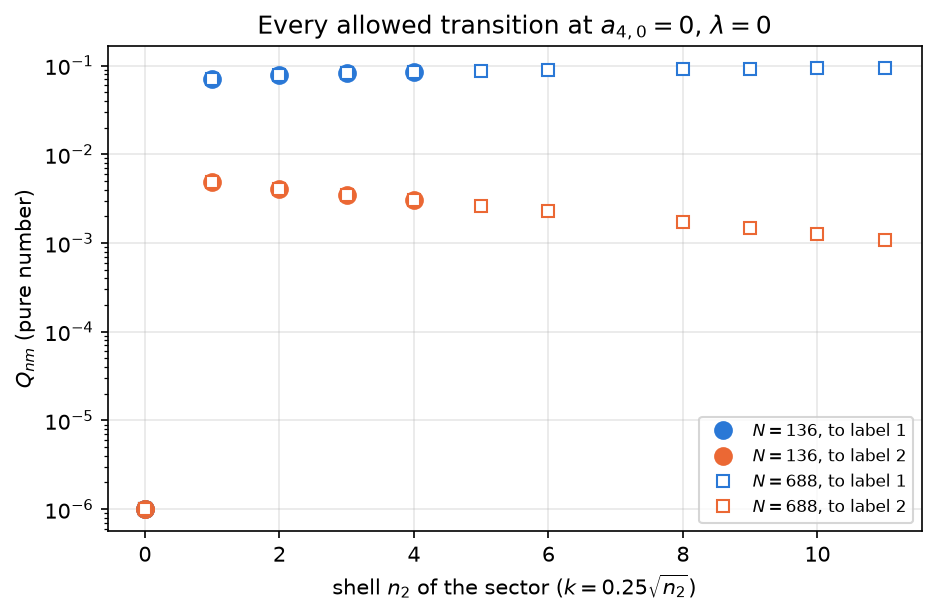

Figure 15c.2 saved as Revision/textbook/figures/15c_2_q_by_pair.png
RESULT largest Q of all free pairs (10 states) = 0.09345
PASS every Q of the free states is below 0.1


In [6]:
fig, ax = plt.subplots()
for marker, n in (("o", 136), ("s", 688)):
    for colour, label in zip(PALETTE, (1, 2)):
        points = [(n2, q) for q, n2, lm in pairs[(n, 0.0)] if lm == label]
        ax.plot([p[0] for p in points], [max(p[1], 1e-6) for p in points], marker,
                color=colour, ms=8 if n == 136 else 6,
                markerfacecolor=colour if n == 136 else "white",
                label=f"$N = {n}$, to label {label}")
ax.set_yscale("log")
ax.set_xlabel("shell $n_2$ of the sector ($k = 0.25\\sqrt{n_2}$)")
ax.set_ylabel("$Q_{nm}$ (pure number)")
ax.set_title("Every allowed transition at $a_{4,0} = 0$, $\\lambda = 0$")
ax.legend(fontsize=8)
save_figure(fig, "q_by_pair",
            "The adiabaticity measure $Q_{nm}$ (vertical axis, logarithmic, pure "
            "number) of every allowed transition of the free states $N = 136$ "
            "(filled) and $N = 688$ (open) at $a_{4,0} = 0$, against the shell "
            "$n_2$ of the sector (horizontal axis); colour: the label of the empty "
            "level. Transitions at $k = 0$ vanish and are drawn at the bottom "
            "($10^{-6}$). All values lie below $0.1$, so the instantaneous states "
            "are followed adiabatically to a good approximation.")
largest = max(q for values in pairs.values() for q, _, _ in values)
report("largest Q of all free pairs (10 states)", f"{largest:.5f}")
check(largest < 0.1, "every Q of the free states is below 0.1")

## 9. Q along the history, for every state of the matrix

The next cell reads $Q_{max}$ of all 75 ground states from the record (with
interaction the self-consistent potentials contribute too) and draws it against the
slice, together with the values computed here for $\lambda = 0$ (black crosses).
$Q_{max}$ falls along the history, because the matrix element carries the factor
$k e^{-a_{4,0}}$. The right panel shows the transition probability $Q_{max}^2$.

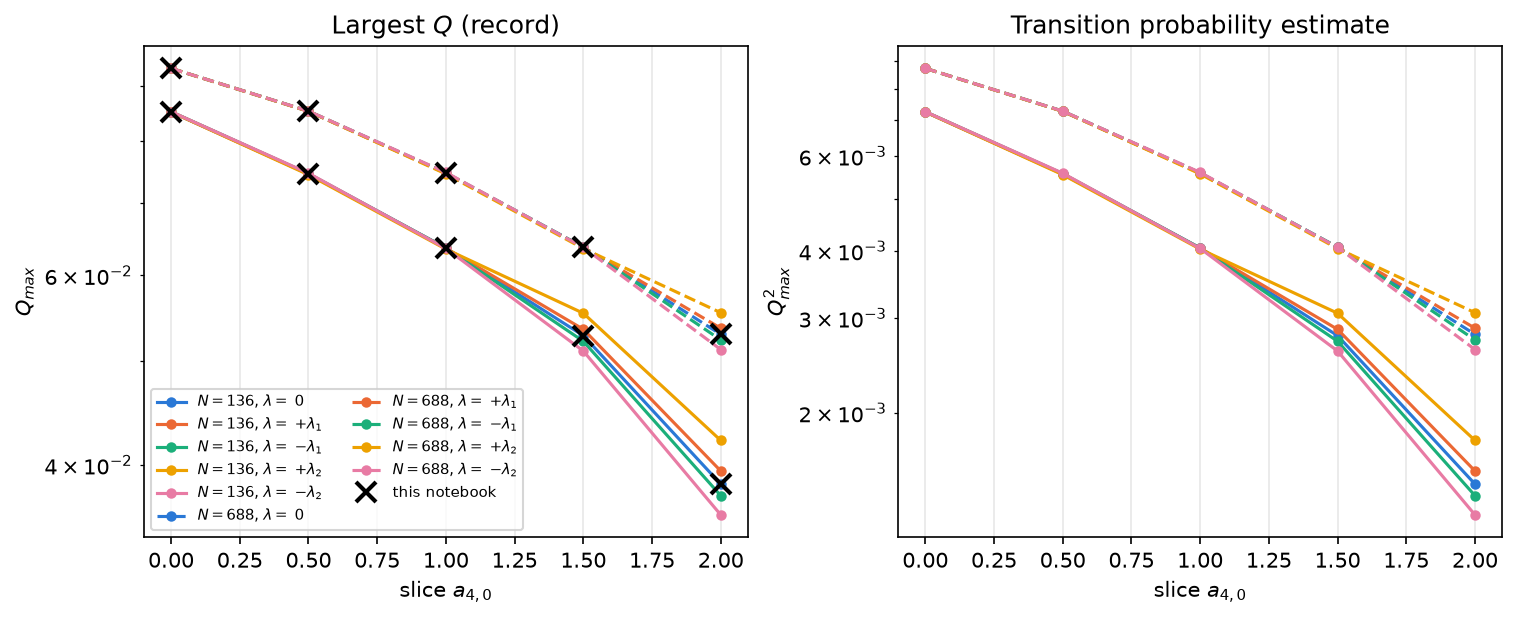

Figure 15c.3 saved as Revision/textbook/figures/15c_3_q_history.png
RESULT largest Q_max of the whole matrix (record) = 0.0935
PASS Q_max <= 0.0935 over the matrix, and Q = 0 exactly for N = 8
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv, column Q_max
PASS Q_max of the free states falls from slice to slice


In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
tags = [("lam0", "$0$"), ("lamp1", "$+\\lambda_1$"), ("lamm1", "$-\\lambda_1$"),
        ("lamp2", "$+\\lambda_2$"), ("lamm2", "$-\\lambda_2$")]
record_max = 0.0
for style, n in (("-", 136), ("--", 688)):
    for colour, (tag, label) in zip(PALETTE, tags):
        values = [float(adiabatic[state_id(n, a4, tag)]["Q_max"]) for a4 in SLICES]
        record_max = max(record_max, max(values))
        left.plot(SLICES, values, style, color=colour, lw=1.5, marker="o", ms=4,
                  label=f"$N = {n}$, $\\lambda = $ {label}")
        right.plot(SLICES, [v * v for v in values], style, color=colour, lw=1.5,
                   marker="o", ms=4)
    mine = [max(q for q, _, _ in pairs[(n, a4)]) for a4 in SLICES]
    left.plot(SLICES, mine, "x", color="black", ms=10, mew=2)
left.plot([], [], "x", color="black", ms=10, mew=2, label="this notebook")
left.set_yscale("log")
left.set_xlabel("slice $a_{4,0}$")
left.set_ylabel("$Q_{max}$")
left.set_title("Largest $Q$ (record)")
left.legend(fontsize=7, ncol=2)
right.set_yscale("log")
right.set_xlabel("slice $a_{4,0}$")
right.set_ylabel("$Q_{max}^2$")
right.set_title("Transition probability estimate")
save_figure(fig, "q_history",
            "Left: the largest adiabaticity measure $Q_{max}$ (vertical axis, "
            "logarithmic) of the 50 ground states with $N = 136$ (solid) and "
            "$N = 688$ (dashed) for the five couplings, against the slice "
            "(horizontal axis), from the record; black crosses: the values "
            "recomputed here for $\\lambda = 0$. Right: the transition probability "
            "estimate $Q_{max}^2$, below $0.009$ everywhere. Both fall along the "
            "history; for $N = 8$ every $Q$ is exactly zero (only $k = 0$ is "
            "occupied).")
n8_zero = all(float(adiabatic[state_id(8, a4, tag)]["Q_max"]) == 0.0
              for a4 in SLICES for tag, _ in tags)
report("largest Q_max of the whole matrix (record)", f"{record_max:.4f}")
check(record_max <= 0.0935 and n8_zero,
      "Q_max <= 0.0935 over the matrix, and Q = 0 exactly for N = 8",
      record=f"{ADIABATIC}, column Q_max")
falling = all(max(q for q, _, _ in pairs[(n, SLICES[i + 1])])
              < max(q for q, _, _ in pairs[(n, SLICES[i])])
              for n in (136, 688) for i in range(4))
check(falling, "Q_max of the free states falls from slice to slice")

## 10. The Hellmann-Feynman theorem and the energy derivative

The next cell takes the occupied brane-band levels of the free state $N = 688$ at
$a_{4,0} = 1$ (shells $n_2 = 1$ to $11$), computes each level also at
$a_{4,0} \pm \delta$ and $\pm 2\delta$ with $\delta = 0.002$ (the solver's step),
forms the **Richardson** combination of the two central differences,
$\tfrac{1}{3}[4 D(\delta) - D(2\delta)]$ with $D(s) = [\varepsilon(a+s) -
\varepsilon(a-s)]/(2s)$ (it removes the error proportional to $\delta^2$), and
compares with the matrix element $\langle n|\partial_a h|n\rangle$. Then it adds up
$dE/da_4 = \sum g f \langle n|\partial_a h|n\rangle$ over all occupied levels,
with the degeneracy $g = 4 r_3(n_2)$, and compares with the derivative the solver
obtained by finite differences of $E$ (column `dE_da4_finite_difference`).

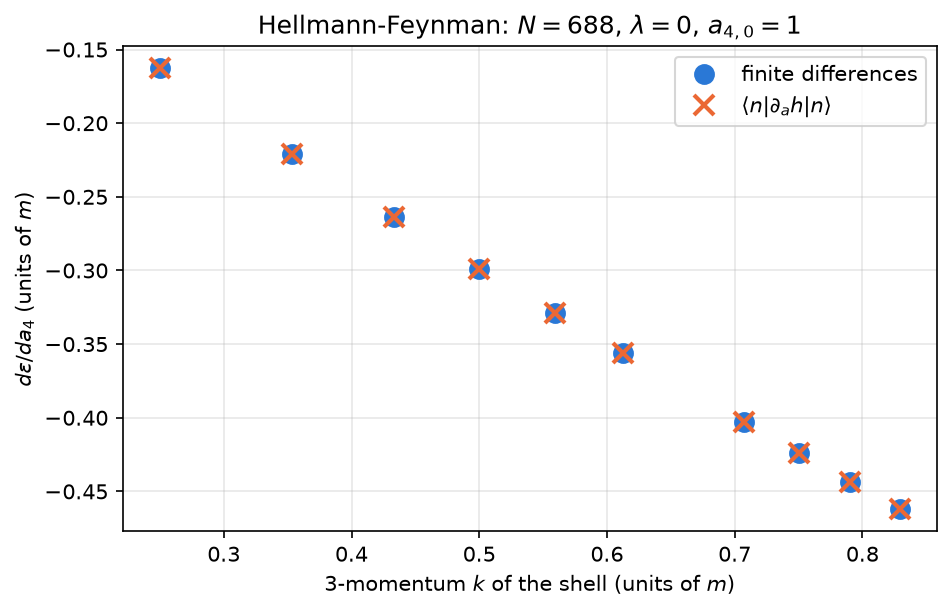

Figure 15c.4 saved as Revision/textbook/figures/15c_4_hellmann_feynman.png
RESULT largest |finite difference - matrix element| = 1.7e-12
RESULT dE/da4 of N688_lam0_a10: Hellmann-Feynman / record = -253.0160345318 /
    -253.0160345309
PASS d eps/da4 = <n| d_a h |n> for the eleven levels within 1e-7
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    adiabatic_hellmann_feynman
PASS dE/da4 = sum g f <n| d_a h |n>
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv, N688_lam0_a10,
    column dE_da4_finite_difference


In [8]:
DELTA = 2e-3
a0 = 1.0
state = states[(688, a0)]
shells, finite, element = [], [], []
for sector, levels in sorted(state.items()):
    if sector[0] == 0:
        continue  # the zero modes do not depend on a4,0
    eps, f, k, r3, orb = levels[0]  # the occupied brane-band level (label 0)
    near = {s: find_level(k, sector[1], sector[2], 0, a0 + s, eps)
            for s in (DELTA, -DELTA, 2 * DELTA, -2 * DELTA)}
    d1 = (near[DELTA] - near[-DELTA]) / (2 * DELTA)
    d2 = (near[2 * DELTA] - near[-2 * DELTA]) / (4 * DELTA)
    shells.append(k)
    finite.append((4.0 * d1 - d2) / 3.0)
    element.append(da_h(k, sector[1], a0, orb, orb))
hf_dev = max(abs(a - b) for a, b in zip(finite, element))
de_da = sum(4.0 * levels[l][3] * levels[l][1] * da_h(levels[l][2], sector[1], a0,
                                                       levels[l][4], levels[l][4])
            for sector, levels in state.items() for l in levels)
recorded = float(adiabatic[state_id(688, a0)]["dE_da4_finite_difference"])
fig, ax = plt.subplots()
ax.plot(shells, finite, "o", color=PALETTE[0], ms=9, label="finite differences")
ax.plot(shells, element, "x", color=PALETTE[1], ms=10, mew=2,
        label="$\\langle n|\\partial_a h|n\\rangle$")
ax.set_xlabel("3-momentum $k$ of the shell (units of $m$)")
ax.set_ylabel("$d\\varepsilon/da_4$ (units of $m$)")
ax.set_title("Hellmann-Feynman: $N = 688$, $\\lambda = 0$, $a_{4,0} = 1$")
ax.legend()
save_figure(fig, "hellmann_feynman",
            "The derivative $d\\varepsilon/da_4$ of the eleven occupied brane-band "
            "levels of the free state $N = 688$ at $a_{4,0} = 1$ (vertical axis, "
            "units of $m$) against their momentum $k$ (horizontal axis): circles "
            "from Richardson finite differences of the levels, crosses from the "
            "matrix element of $\\partial_a h = -j\\kappa k\\sigma_3$. They agree "
            "(the Hellmann-Feynman theorem); every level falls along the history, "
            "faster for larger $k$.")
report("largest |finite difference - matrix element|", f"{hf_dev:.1e}")
report("dE/da4 of N688_lam0_a10: Hellmann-Feynman / record",
       f"{de_da:.10f} / {recorded:.10f}")
check(hf_dev < 1e-7, "d eps/da4 = <n| d_a h |n> for the eleven levels within 1e-7",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "adiabatic_hellmann_feynman")
check(abs(de_da / recorded - 1.0) < 1e-9, "dE/da4 = sum g f <n| d_a h |n>",
      record=f"{ADIABATIC}, N688_lam0_a10, column dE_da4_finite_difference")

## 11. When the Fermi level is crossed

Adiabatic evolution keeps the occupation of every level. If an empty level comes
down below an occupied one along the history (a **Fermi-level crossing**), the
instantaneous ground state fills the new lower level, but the adiabatically
evolving gas cannot get there: the two levels lie in different sectors, and the
exact evolution never moves a particle between sectors. The canonical matrix has no
such crossing (the record file `adiabatic/fermi-level-crossings.csv`). The record's
demonstration uses $N = 696 = 688 + 8$: at $a_{4,0} = 0$ the eight extra particles
sit in the odd bulk level at $k = 0$ ($\varepsilon = 1.2923$, which does not move),
while the brane band of the shell $n_2 = 12$ ($k = 0.25\sqrt{12} = 0.866$, 32
orbitals) lies above it and comes down along the history. The next cell computes
both levels, finds the slice where they cross by bisection, and computes the
energy by which the adiabatically continued state lies above the instantaneous
ground state, $8\,(\varepsilon_{odd} - \varepsilon_{12})$ (the eight particles of
the $k = 0$ level would sit in the band level instead), at the five slices.

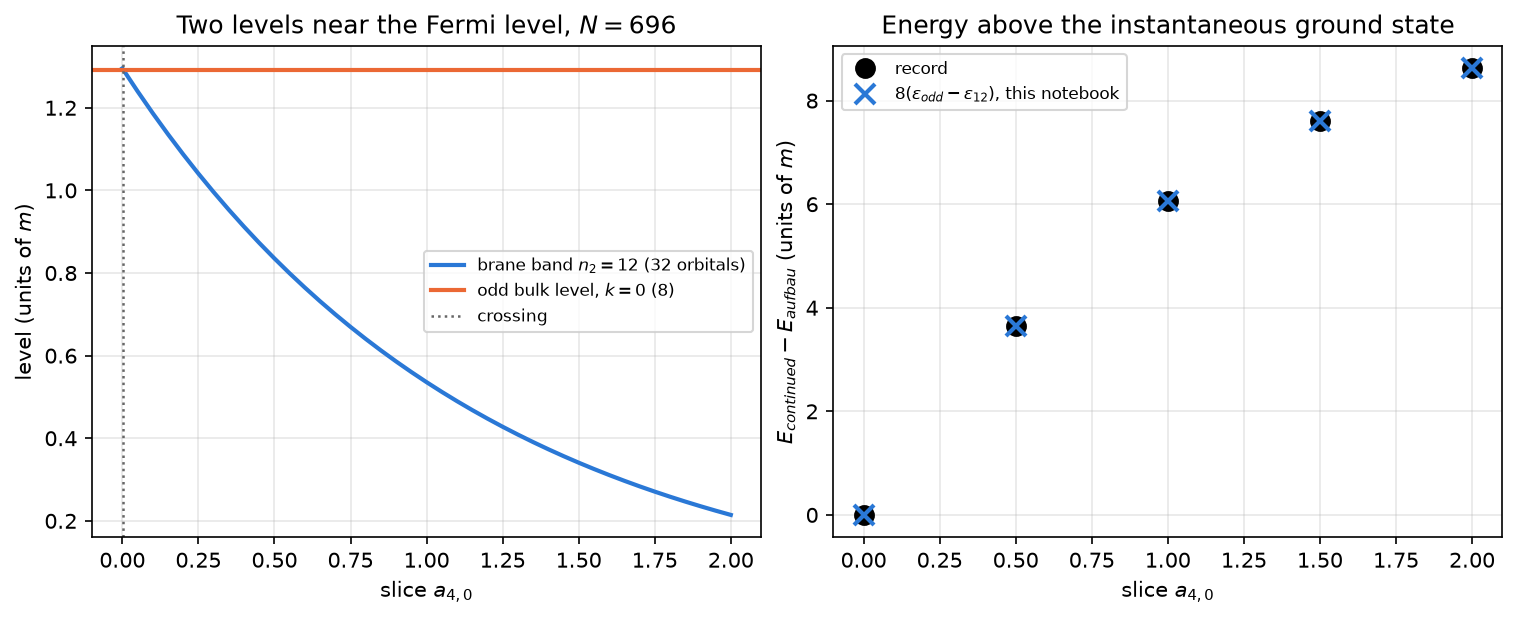

Figure 15c.5 saved as Revision/textbook/figures/15c_5_fermi_crossing.png
RESULT band level n2 = 12 minus the odd level at a4,0 = 0 = 0.0032325390
RESULT crossing slice a4,0 = 0.002854
RESULT largest |8 (eps_odd - eps_12) - recorded difference| = 2.0e-11
PASS the crossing lies between the slices 0 and 0.5
     reproduces Revision/kohn_sham/results/adiabatic/crossing-demo.csv, flags at 0 and
    0.5
PASS the energy differences of the demonstration reproduced
     reproduces Revision/kohn_sham/results/adiabatic/crossing-demo.csv, column difference


In [9]:
K12 = 0.25 * math.sqrt(12.0)
eps_odd = find_level(0.0, 1, "odd", 0, 0.0, 1.29)  # the k = 0 odd bulk level


def band12(a4):
    """The brane-band level of the shell n2 = 12 at the slice a4."""
    return find_level(K12, 1, "even", 0, a4, 1.9 * K12 * math.exp(-a4))


lo, hi = 0.0, 0.5  # bisection for band12(a4) = eps_odd
for _ in range(45):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if band12(mid) > eps_odd else (lo, mid)
crossing = 0.5 * (lo + hi)
dense = np.linspace(0.0, 2.0, 41)
band_curve = [band12(a) for a in dense]
with open(repository_file("Revision/kohn_sham/results/adiabatic/crossing-demo.csv"),
          newline="", encoding="utf-8") as handle:
    demo = {float(row["a4"]): row for row in csv.DictReader(handle)}
mine = {a4: max(0.0, 8.0 * (eps_odd - band12(a4))) for a4 in SLICES}
worst_demo = max(abs(mine[a4] - float(demo[a4]["difference"])) for a4 in SLICES)
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
left.plot(dense, band_curve, color=PALETTE[0], lw=2.0,
          label="brane band $n_2 = 12$ (32 orbitals)")
left.axhline(eps_odd, color=PALETTE[1], lw=2.0, label="odd bulk level, $k = 0$ (8)")
left.axvline(crossing, color="0.4", ls=":", lw=1.2, label="crossing")
left.set_xlabel("slice $a_{4,0}$")
left.set_ylabel("level (units of $m$)")
left.set_title("Two levels near the Fermi level, $N = 696$")
left.legend(fontsize=8)
right.plot(SLICES, [float(demo[a]["difference"]) for a in SLICES], "o", color="black",
           ms=9, label="record")
right.plot(SLICES, [mine[a] for a in SLICES], "x", color=PALETTE[0], ms=10, mew=2,
           label="$8(\\varepsilon_{odd} - \\varepsilon_{12})$, this notebook")
right.set_xlabel("slice $a_{4,0}$")
right.set_ylabel("$E_{continued} - E_{aufbau}$ (units of $m$)")
right.set_title("Energy above the instantaneous ground state")
right.legend(fontsize=8)
save_figure(fig, "fermi_crossing",
            "The Fermi-level crossing of the demonstration state $N = 696$ without "
            "interaction. Left: the brane-band level of the shell $n_2 = 12$ (blue) "
            "falls along the history and crosses the fixed odd bulk level at $k = 0$ "
            "(orange) almost at once, at $a_{4,0} = 0.0029$ (dotted line), because "
            "at $a_{4,0} = 0$ it lies only $0.0032\\,m$ above it; vertical axis in "
            "units of $m$. Right: the energy by which the adiabatically continued "
            "state lies "
            "above the instantaneous aufbau state (vertical axis, units of $m$), "
            "from the record (dots) and from the two levels (crosses), at the five "
            "slices.")
report("band level n2 = 12 minus the odd level at a4,0 = 0",
       f"{band_curve[0] - eps_odd:.10f}")
report("crossing slice a4,0", f"{crossing:.6f}")
report("largest |8 (eps_odd - eps_12) - recorded difference|", f"{worst_demo:.1e}")
check(0.0 < crossing < 0.5, "the crossing lies between the slices 0 and 0.5",
      record="Revision/kohn_sham/results/adiabatic/crossing-demo.csv, flags at 0 "
             "and 0.5")
check(worst_demo < 1e-9, "the energy differences of the demonstration reproduced",
      record="Revision/kohn_sham/results/adiabatic/crossing-demo.csv, column "
             "difference")

## 12. The whole matrix at a glance

The last figure is a heat map of $Q_{max}$ from the record: one row per series
(particle number and coupling), one column per slice, darker for larger values.
The check reads the record file of Fermi-level crossings and confirms that none of
its 60 rows (15 series, 4 steps between slices) reports a change of the occupied set.

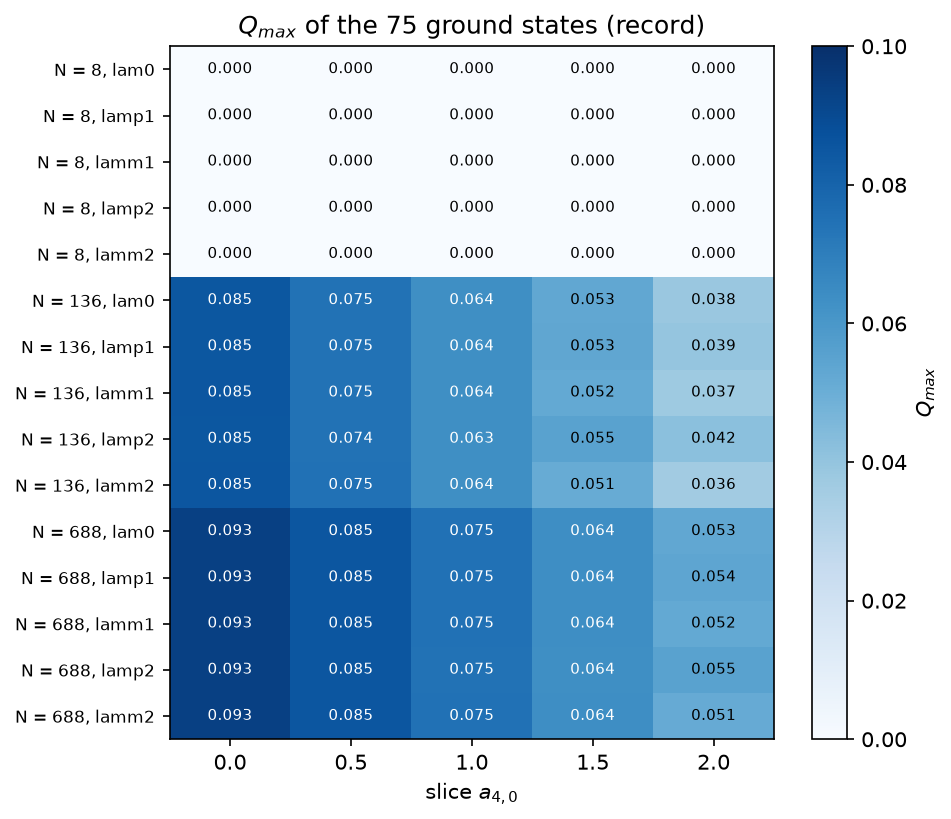

Figure 15c.6 saved as Revision/textbook/figures/15c_6_q_map.png
RESULT rows of the crossing record / rows with a changed occupied set = 60 / 0
PASS no Fermi-level crossing in the canonical matrix
     reproduces Revision/kohn_sham/results/adiabatic/fermi-level-crossings.csv


In [10]:
rows, names = [], []
for n in (8, 136, 688):
    for tag, label in tags:
        rows.append([float(adiabatic[state_id(n, a4, tag)]["Q_max"]) for a4 in SLICES])
        names.append(f"N = {n}, {tag}")
table = np.array(rows)
fig, ax = plt.subplots(figsize=(6.5, 6.0))
image = ax.imshow(table, cmap="Blues", aspect="auto", vmin=0.0, vmax=0.1)
ax.grid(False)  # no grid lines across the coloured squares
ax.set_xticks(range(5), [f"{a:.1f}" for a in SLICES])
ax.set_yticks(range(len(names)), names, fontsize=8)
for i in range(table.shape[0]):
    for jj in range(table.shape[1]):
        ax.text(jj, i, f"{table[i, jj]:.3f}", ha="center", va="center", fontsize=7,
                color="white" if table[i, jj] > 0.06 else "black")
ax.set_xlabel("slice $a_{4,0}$")
ax.set_title("$Q_{max}$ of the 75 ground states (record)")
fig.colorbar(image, ax=ax, label="$Q_{max}$")
save_figure(fig, "q_map",
            "Heat map of the largest adiabaticity measure $Q_{max}$ of the 75 ground "
            "states of the canonical matrix (record): rows are the particle numbers "
            "$N = 8$, $136$, $688$ with the couplings $0$, $\\pm\\lambda_1$, "
            "$\\pm\\lambda_2$ (tags lam0, lamp1, lamm1, lamp2, lamm2), columns the "
            "slices $a_{4,0}$; the printed numbers are the values. Every value is "
            "below $0.1$, the largest at the start of the history.")
with open(repository_file("Revision/kohn_sham/results/adiabatic/"
                          "fermi-level-crossings.csv"), newline="",
          encoding="utf-8") as handle:
    crossings = list(csv.DictReader(handle))
changed = sum(row["occupied_set_changed"] == "true" for row in crossings)
report("rows of the crossing record / rows with a changed occupied set",
       f"{len(crossings)} / {changed}")
check(len(crossings) == 60 and changed == 0,
      "no Fermi-level crossing in the canonical matrix",
      record="Revision/kohn_sham/results/adiabatic/fermi-level-crossings.csv")

## 13. The last check

The last cell checks that every figure file of this notebook exists and prints the
number of checks that passed.

In [11]:
NAMES = ["transition_orbitals", "q_by_pair", "q_history", "hellmann_feynman",
         "fermi_crossing", "q_map"]
missing = [name for number, name in enumerate(NAMES, start=1)
           if not output_file(f"{FIGURE_FOLDER}/15c_{number}_{name}.png").is_file()]
check(missing == [], "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 12 CHECKS PASSED (notebook 15c)


## 14. What this notebook showed

- The adiabaticity measure $Q_{nm} = AH|\langle n|\partial_a h|m\rangle|/
  (\varepsilon_n - \varepsilon_m)^2$ is the first-order amplitude of a jump between
  instantaneous levels of one sector; its derivation needs only the product rule and
  the integral of a rotating phase.
- Recomputed in plain Python, every level, the largest $Q$, its pair, its energy
  difference and its matrix element of the free states agree with the Rust
  solver's record (COMPUTED).
- $Q_{max} \le 0.0935$ over the whole canonical matrix (transition probability
  below $0.009$) and it decreases along the history: the instantaneous states are
  followed adiabatically, within the sectors, to a good approximation.
- The Hellmann-Feynman theorem holds, and the energy falls along the history at the
  rate $\sum g f\langle n|\partial_a h|n\rangle$.
- When a level crosses the Fermi level (the demonstration $N = 696$), the
  instantaneous ground state is not the state that the evolution reaches: there the
  instantaneous picture fails, by $3.66$ to $8.62\,m$ in energy. The full
  time-dependent problem is OPEN.